# TASK B2: Spatial Heterogeneity Analysis

## Setup

In [20]:
import numpy as np
import pandas as pd
from pathlib import Path
import sys, json, subprocess

import matplotlib.pyplot as plt

import io
import imageio

from scipy.stats import wilcoxon
from scipy.stats import mannwhitneyu


In [21]:
# ── project layout ────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = PROJECT_ROOT / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs/spatial'

OUTPUT_ROOT.mkdir(exist_ok=True)

# ── spatiotemporal signal propagation graph construction parameters ────────────
SIGNAL_COL    = 'ERKKTR_ratio'
SPATIAL_RADIUS = 60
FUTURE_WINDOW  = 3
JUMP_QUANTILE  = 0.9

# ── helper: path to outputs for a given run ───────────────────────────────────
def output_dir(exp, site, signal=SIGNAL_COL):
    return OUTPUT_ROOT / f'exp_{exp}_site_{site}_{signal}'

def load_summary(exp, site, signal=SIGNAL_COL):
    path = output_dir(exp, site, signal) / 'summary.json'
    with open(path) as f:
        return json.load(f)

print('Project root:', PROJECT_ROOT)
print('Data file exists:', DATA_PATH.exists())

Project root: /home/mykyta/Документи/PycharmProjects/UW-SysBiol-Project2
Data file exists: True


## Part 1: Demonstration of the spatial classification algorithm on a single (Exp_id, Image_Metadata_Site) block


In [22]:
# Run spatiotemporal signal propagation script on single set block.

# Block to choose
EXP_ID = 1
SITE_ID = 1

cmd = [
    sys.executable,
    str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
    '--data-path',           str(DATA_PATH),
    '--meta-path',           str(META_PATH),
    '--exp-id',              str(EXP_ID),
    '--site-id',             str(SITE_ID),
    '--signal-col',          SIGNAL_COL,
    '--spatial-radius',      str(SPATIAL_RADIUS),
    '--future-window-frames', str(FUTURE_WINDOW),
    '--jump-quantile',       str(JUMP_QUANTILE),
    '--output-dir',          str(OUTPUT_ROOT),
]

print('Running script …')
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

Running script …

Spatiotemporal graph analysis complete.
Output directory: /home/mykyta/Документи/PycharmProjects/UW-SysBiol-Project2/analysis_outputs/spatial/exp_1_site_1_ERKKTR_ratio
Mutation: WT
Nodes: 356,632
Spatial edges: 2,389,504
Temporal edges: 354,834
Jump threshold on ERKKTR_ratio: 0.0365
Interpretation of "jump": a large upward change since the previous frame.
Neighbour jump now means: at least one nearby cell shows such a large upward change at the current frame.
Future self jump means: the same cell shows such a large upward change within the next 3 frames.
Future jump rate with neighbour jump now: 0.13145546310189607
Future jump rate without neighbour jump now: 0.07486715044854579
Risk difference: 0.05658831265335028 (absolute probability gap; 0.05 means 5 percentage points higher).
Relative risk: 1.7558496926130764 (times more likely; 1 means no difference, >1 means more likely).



## Spatial categorization algorithm description: Dynamic Frame-by-Frame Percentile Bounding

To analyze spatial heterogeneity and investigate potential boundary effects, cells must be classified into **Edge** and **Central** regions.

#### The Challenge with Static Boundaries
A naive approach would use fixed absolute coordinate thresholds (e.g., $X < 100$ or $X > 900$). However, this fails in real-world live-imaging data because the cell monolayer dynamically moves, expands, or contracts over time. If a colony shrinks, static borders might end up measuring empty space or misclassifying central cells as edge cells.

#### Our Solution: Dynamic Percentile Bounding
To overcome this, our algorithm applies **dynamic frame-by-frame percentile thresholding**. At every single time point ($t$), the coordinate distribution of all visible cells is evaluated independently:

1. **Border Calculation:** For each frame, we compute the lower and upper percentiles (defined by the `EDGE_MARGIN_PERCENTILE` parameter, default $5\%$) for both $X$ and $Y$ coordinates:
   $$X_{low} = \text{Percentile}(X, 5\%), \quad X_{high} = \text{Percentile}(X, 95\%)$$
   $$Y_{low} = \text{Percentile}(Y, 5\%), \quad Y_{high} = \text{Percentile}(Y, 95\%)$$

2. **Classification Rule:** A cell is categorized as an **Edge cell** if its coordinates fall outside this adaptive inner bounding box. Otherwise, it is classified as a **Central cell**:
   $$\text{Category} = \begin{cases}
   \text{'edge'}, & \text{if } X \le X_{low} \text{ or } X \ge X_{high} \text{ or } Y \le Y_{low} \text{ or } Y \ge Y_{high} \\
   \text{'central'}, & \text{otherwise}
   \end{cases}$$

This approach ensures that **Edge cells** always represent the true physical periphery of the imaged cell population at that specific moment, regardless of experimental shifts.

In [23]:
EDGE_MARGIN_PERCENTILE = 5

In [24]:
# applying classification onto result
nodes = pd.read_csv(output_dir(EXP_ID, SITE_ID) / 'nodes.csv.gz')
from scripts.spatial_edge_propagation_analysis import classify_frame_edges

nodes['spatial_category'] = nodes.groupby('Image_Metadata_T').apply(
    lambda g: pd.Series(classify_frame_edges(g,EDGE_MARGIN_PERCENTILE), index=g.index)
).reset_index(level=0, drop=True)

### A quick visual demonstration of how groups are assigned on a single time snapshot


In [ ]:
SNAPSHOT_TIME = 1

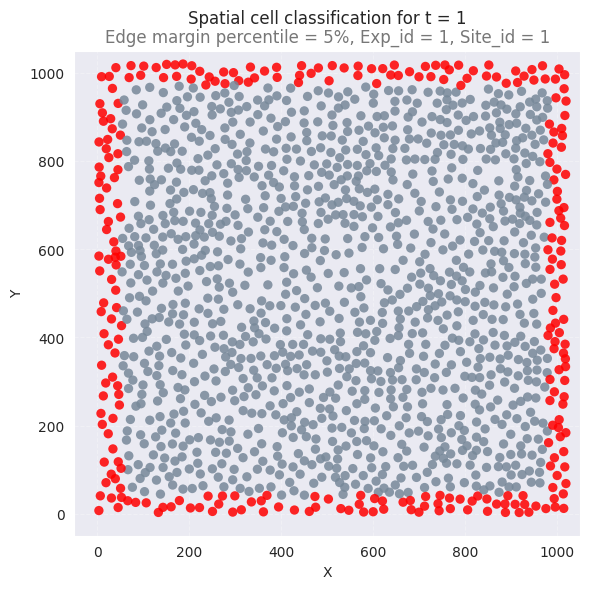

In [25]:

def spatial_classification_visualisation(snapshot):
    """Generates a scatter plot for a single time frame showing edge vs central cells."""
    # Extract the current time point directly from the snapshot data
    t = snapshot["Image_Metadata_T"].iloc[0]

    # Map colors based on the dynamic spatial category
    colors = np.where(
        snapshot["spatial_category"] == "edge", "red", "lightslategray"
    )

    # Initialize the plot with fixed square dimensions
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        snapshot["objNuclei_Location_Center_X"],
        snapshot["objNuclei_Location_Center_Y"],
        c=colors,
        s=45,
        alpha=0.85,
        edgecolor="none",
    )

    # Set rigid limits for X and Y axes to prevent jumping during animation
    ax.set_xlim(-50, 1050)
    ax.set_ylim(-50, 1050)

    # Main title with padding to make room for the subtitle
    ax.set_title(f"Spatial cell classification for t = {t}", pad=20)

    # Subtitle indicating the percentile used
    ax.text(0.5, 1.01, f"Edge margin percentile = {EDGE_MARGIN_PERCENTILE}%, Exp_id = {snapshot["Exp_ID"].iloc[0]}, Site_id = {snapshot["Image_Metadata_Site"].iloc[0]}", transform=ax.transAxes,
        fontsize=12, color="#777777", ha="center", va="bottom",
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    return fig


snapshot = nodes[nodes["Image_Metadata_T"] == SNAPSHOT_TIME]
single_fig = spatial_classification_visualisation(snapshot)

### The same classification demonstration but for the whole time period
A gif of the all such scatter plots is saved to the `OUTPUT_ROOT`

In [26]:
# Sort time points to ensure chronological order in the GIF
time_points = sorted(nodes["Image_Metadata_T"].unique())
frames_images = []

print("Generating frames...")
for t in time_points:
    # Filter data for the current frame
    snapshot = nodes[nodes["Image_Metadata_T"] == t]

    if snapshot.empty:
        continue

    # 1. Call the standalone visualization function to create the figure
    fig = spatial_classification_visualisation(snapshot)

    # 2. Save the current figure directly to a memory buffer
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    buf.seek(0)

    # 3. Read the image from buffer and append to the frames list
    frames_images.append(imageio.v2.imread(buf))

    # 4. Close the plot to release memory immediately
    plt.close(fig)

# Save all gathered frames into an animated GIF
output_gif_path = OUTPUT_ROOT / "cell_propagation_boundaries.gif"
imageio.mimsave(output_gif_path, frames_images, fps=20, loop=0)

print(f"Animated GIF successfully saved to: {output_gif_path}")

Generating frames...
Animated GIF successfully saved to: /home/mykyta/Документи/PycharmProjects/UW-SysBiol-Project2/analysis_outputs/spatial/cell_propagation_boundaries.gif


### Dynamics of the cell counts classified to each category for the set block
Because of the dynamic nature of the classification, an exact number of cells belonging to each category can't be stated for the time period > 1.

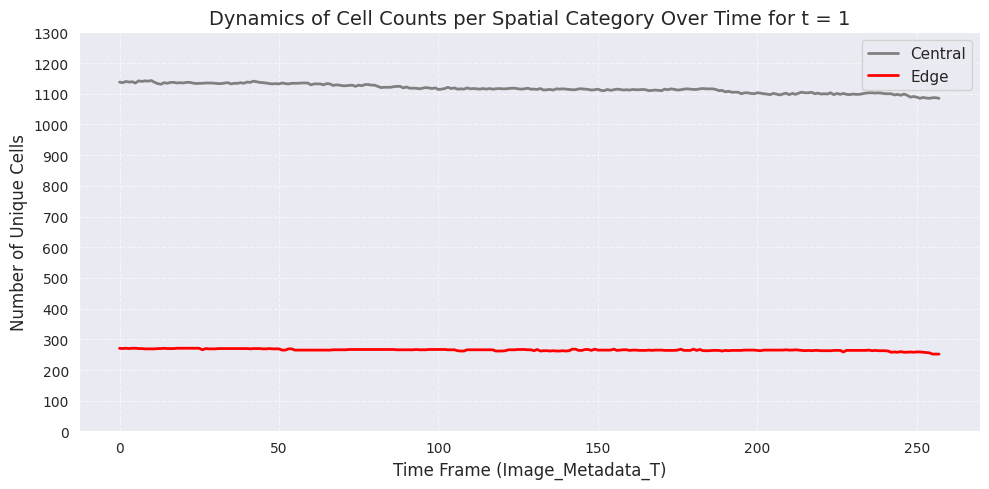

In [27]:
# We count unique track_ids at each time point (frame) for each spatial category
counts_per_frame = (
    nodes.groupby(["Image_Metadata_T", "spatial_category"])["track_id"]
    .nunique()
    .unstack(fill_value=0)
)
fig, ax = plt.subplots(figsize=(10, 5))

# Plot central cells (gray)
ax.plot(
    counts_per_frame.index,
    counts_per_frame["central"],
    color="gray",
    linestyle="-",
    linewidth=2,
    label="Central",
)

# Plot edge cells (red)
ax.plot(
    counts_per_frame.index,
    counts_per_frame["edge"],
    color="red",
    linestyle="-",
    linewidth=2,
    label="Edge",
)

# Chart styling
ax.set_title(f"Dynamics of Cell Counts per Spatial Category Over Time for t = {SNAPSHOT_TIME}", fontsize=14)
ax.set_xlabel("Time Frame (Image_Metadata_T)", fontsize=12)
ax.set_ylabel("Number of Unique Cells", fontsize=12)
ax.set_yticks(ticks = range(0, max(counts_per_frame["central"]) + 200,100))

ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="best", fontsize=11)

plt.savefig(OUTPUT_ROOT / "n_cells_by_category_example_plot.png",
    bbox_inches='tight')
plt.tight_layout()
plt.show()

As we see both center node count and edge node count barely changes meaning most cells don't change their category through all recording. However, some cells do definitely jump between categories as seen on a previous gif.

## Part 2: Collecting RR,RD and neighbour count metrics from multiple blocks
Here we switch from simple demonstrations to real analysis of more than one block. This way we can collect multiple $RR_{edge}$ and $RR_{central}$ for each site and then compare those 2 sets using Wilcoxon Signed-Rank Test to statistically prove or disprove if $RR$ actually differs between center and edge cells.

In [28]:
# Listing all existing (Exp_id, Image_Metadata_Site) blocks present in data
CHUNKSIZE = 1_000_000

# importing already implemented function for such task
from scripts.compare_spatiotemporal_behavior import find_available_blocks

print("Scanning the large dataset to find all available blocks...")

available_blocks_df = find_available_blocks(DATA_PATH, chunksize=CHUNKSIZE)

print(f"\nSuccessfully found {len(available_blocks_df)} available blocks across the dataset:")

all_blocks_tuples = list(available_blocks_df.itertuples(index=False, name=None))
print(all_blocks_tuples)

Scanning the large dataset to find all available blocks...

Successfully found 120 available blocks across the dataset:
[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19), (1, 20), (2, 1), (2, 2), (2, 3), (2, 4), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (2, 14), (2, 15), (2, 16), (2, 17), (2, 18), (2, 19), (2, 20), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (3, 10), (3, 11), (3, 12), (3, 13), (3, 14), (3, 15), (3, 16), (3, 17), (3, 18), (3, 19), (3, 20), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (4, 10), (4, 11), (4, 12), (4, 13), (4, 14), (4, 15), (4, 16), (4, 17), (4, 18), (4, 19), (4, 20), (5, 1), (5, 2), (5, 3), (5, 4), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13), (5, 14), (5, 15), (5, 16), (5, 17), (5, 18), (5, 20), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6), (6, 7), (

## Batch Execution: Automated Spatial Edge Propagation Pipeline

This section orchestrates the batch execution of our custom processing pipeline (`spatial_edge_propagation_analysis.py`) via a background subprocess.

#### Pipeline Objectives & Operations:
* **Pass-by-Pass Memory Optimization:** To avoid Out-of-Memory kernel crashes, the script streams and loads single-cell trajectory dataset columns chunk-by-chunk, processing specified `Experiment IDs` sequentially and clearing RAM dynamically after each cycle.
* **Graph Reconstruction & Dynamic Partitioning:** Within each distinct experiment site, the underlying spatiotemporal network architecture is reconstructed natively (tracking ERK signal deltas, identifying dynamic kinase activation "jumps", mapping 60-micron neighbor links, and verifying near-future target cell responses).
* **Automated Boundary Categorization:** Cells are dynamically segmented into *Edge* or *Central* populations per frame based on the 10th/90th spatial coordinate percentiles.
* **Statistical and Metric Extraction:** The workflow isolates cell-time nodes by zone to independently quantify propagation metrics (Relative Risk, Risk Difference, and mean connectivity), while running an internal Mann-Whitney U test on the raw neighbor counts for every individual block.

*The aggregated site-level records across all selected experiments are saved directly into a single compact summary table (`spatial_edge_comparison_summary.csv`) for fast analytical exploration.*

All 120 sites from 6 experiments were included in the analysis.


In [ ]:
EDGE_MARGIN_PERCENTILE = 5.0

# Choose which experiments to batch analyze (e.g., Experiments 1, 2, and 3)
CHOSEN_EXP_IDS = [1, 2, 3, 4, 5, 6]

cmd = [
    sys.executable,
    str(SCRIPTS_DIR / "spatial_edge_propagation_analysis.py"),
    "--data-path",
    str(DATA_PATH),
    "--meta-path",
    str(META_PATH),
    "--signal-col",
    SIGNAL_COL,
    "--spatial-radius",
    str(SPATIAL_RADIUS),
    "--future-window-frames",
    str(FUTURE_WINDOW),
    "--jump-quantile",
    str(JUMP_QUANTILE),
    "--edge-margin-percentile",
    str(EDGE_MARGIN_PERCENTILE),
    "--output-dir",
    str(OUTPUT_ROOT),
    "--chosen-exp-ids",
] + [str(eid) for eid in CHOSEN_EXP_IDS]

print("Running batch spatial boundary analysis script...")
result = subprocess.run(cmd, capture_output=True, text=True)

# Output results and telemetry logs directly inside the notebook cell
print(result.stdout)
if result.returncode != 0:
    print("ERROR OCCURRED (STDERR):", result.stderr)

## Results

In [39]:
summary_file_path = OUTPUT_ROOT / 'spatial_edge_comparison_summary.csv'
summary_df = pd.read_csv(summary_file_path)

print(f"Spatial Boundary Metrics Table (First 30 of the {summary_df.shape[0]} sites)")
display(summary_df.head(30))

Spatial Boundary Metrics Table (First 30 of the 120 sites)


,Exp_ID,Site_ID,rr_edge,rr_central,rd_edge,rd_central,mean_neighbors_edge,mean_neighbors_central,mw_p_value
0,1,1,1.610716,1.814384,0.055072,0.057725,10.595555,14.067014,0.0
1,1,2,1.492939,1.877905,0.044463,0.057380,9.868986,13.497436,0.0
2,1,3,1.463024,1.685238,0.038419,0.048151,10.552315,14.055215,0.0
3,1,4,1.786482,1.901620,0.055152,0.061821,11.228979,15.017392,0.0
4,1,5,1.505537,1.642899,0.065118,0.057106,14.330234,17.925165,0.0
5,1,6,1.785359,2.066322,0.073054,0.086164,12.730841,18.788018,0.0
6,1,7,2.097320,2.437509,0.097524,0.099521,11.716586,15.367858,0.0
7,1,8,2.049827,2.102795,0.095089,0.083194,13.485992,17.232156,0.0
8,1,9,1.512782,1.659144,0.047115,0.055646,9.222874,12.933080,0.0
9,1,10,1.537858,1.819874,0.050270,0.066071,10.126460,13.874194,0.0


### Number of sites where edge cells show higher RR or RD then the central cells

In [43]:

higher_rr = summary_df["rr_edge"] > summary_df["rr_central"]
higher_rd = summary_df["rd_edge"] > summary_df["rd_central"]


total_sites = summary_df.dropna(subset=["rr_edge", "rr_central"]).shape[0]
print(f"Total analyzed sites: {total_sites}")
print("-" * 40)
print(
    f"Sites where RR_edge > RR_central: {higher_rr.sum()} ({higher_rr.mean():.1%})"
)
print(
    f"Sites where RD_edge > RD_central: {higher_rd.sum()} ({higher_rd.mean():.1%})"
)

Total analyzed sites: 120
----------------------------------------
Sites where RR_edge > RR_central: 19 (15.8%)
Sites where RD_edge > RD_central: 43 (35.8%)


## Multi-Panel Visualization: Quantifying Boundary Geometrical and Propagation Effects

This cell visualizes the compiled dataset of all processed sites.  **The sites along the X-axis are sorted independently for each subplot by the ascending value of the 'Central' cell population.**

#### Subplot Breakdowns & Interpretations:
1. **Panel 1: Relative Risk (RR) Comparison** Plots the relative probability amplification of a cell undergoing a near-future jump given a current neighboring jump event. If the red curve (Edge) consistently sags beneath the gray curve (Central), it signifies that signal propagation wave transmission is compromised near the boundaries.
2. **Panel 2: Risk Difference (RD) Comparison**
   Evaluates the absolute mathematical probability gap between neighbor-exposed and unexposed cell-time observations. This serves as a secondary verification of total propagation effect sizes across both zones.
3. **Panel 3: Mean Neighbor Count Comparison**
   Provides a direct visual audit of the physical network connectivity.
.

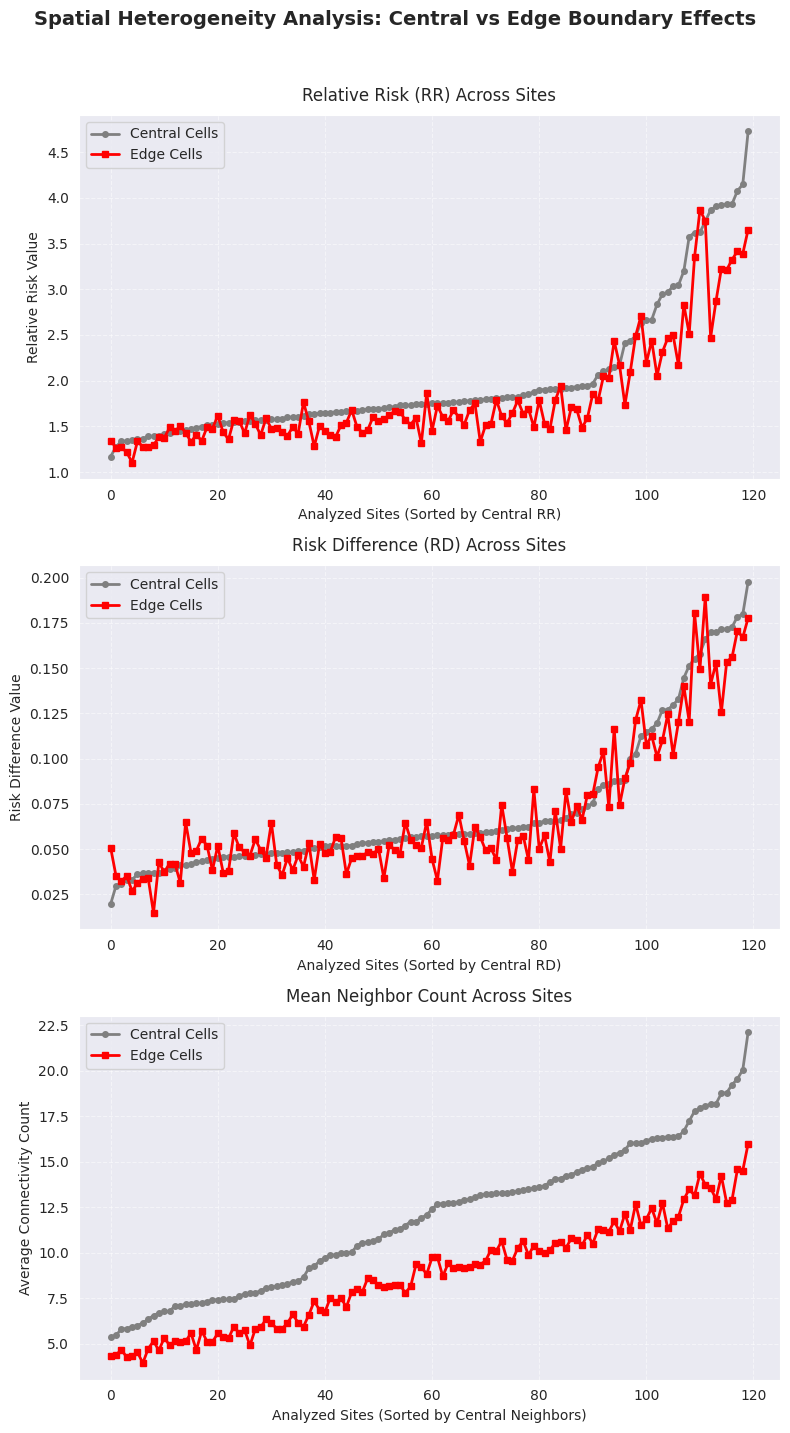

In [36]:
# Drop any potential NaN values to ensure continuous lines on the plots
plot_df = summary_df.dropna(
    subset=[
        "rr_central",
        "rr_edge",
        "rd_central",
        "rd_edge",
        "mean_neighbors_central",
        "mean_neighbors_edge",
    ]
).copy()

# Create a dummy index for the X-axis representing sorted sequential site counts
plot_df = plot_df.reset_index(drop=True)
x_axis = range(len(plot_df))

fig, ax = plt.subplots(figsize=(8, 14), nrows=3, ncols=1)

# --- Subplot 0: Relative Risk (RR) Comparison ---
# Sort by central RR to make the visualization clean and easy to interpret
df_rr = plot_df.sort_values(by="rr_central").reset_index(drop=True)

ax[0].plot(
    x_axis,
    df_rr["rr_central"],
    color="gray",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Central Cells",
)
ax[0].plot(
    x_axis,
    df_rr["rr_edge"],
    color="red",
    linewidth=2,
    marker="s",
    markersize=4,
    label="Edge Cells",
)

ax[0].set_title("Relative Risk (RR) Across Sites", fontsize=12, pad=10)
ax[0].set_xlabel("Analyzed Sites (Sorted by Central RR)", fontsize=10)
ax[0].set_ylabel("Relative Risk Value", fontsize=10)
ax[0].grid(True, linestyle="--", alpha=0.5)
ax[0].legend(loc="best")

# --- Subplot 1: Risk Difference (RD) Comparison ---
# Sort by central RD for visual alignment
df_rd = plot_df.sort_values(by="rd_central").reset_index(drop=True)

ax[1].plot(
    x_axis,
    df_rd["rd_central"],
    color="gray",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Central Cells",
)
ax[1].plot(
    x_axis,
    df_rd["rd_edge"],
    color="red",
    linewidth=2,
    marker="s",
    markersize=4,
    label="Edge Cells",
)

ax[1].set_title("Risk Difference (RD) Across Sites", fontsize=12, pad=10)
ax[1].set_xlabel("Analyzed Sites (Sorted by Central RD)", fontsize=10)
ax[1].set_ylabel("Risk Difference Value", fontsize=10)
ax[1].grid(True, linestyle="--", alpha=0.5)
ax[1].legend(loc="best")

# --- Subplot 2: Mean Neighbors Count Comparison ---
# Sort by central neighbor count to demonstrate the geometric boundary effect
df_neigh = plot_df.sort_values(by="mean_neighbors_central").reset_index(drop=True)

ax[2].plot(
    x_axis,
    df_neigh["mean_neighbors_central"],
    color="gray",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Central Cells",
)
ax[2].plot(
    x_axis,
    df_neigh["mean_neighbors_edge"],
    color="red",
    linewidth=2,
    marker="s",
    markersize=4,
    label="Edge Cells",
)

ax[2].set_title("Mean Neighbor Count Across Sites", fontsize=12, pad=10)
ax[2].set_xlabel("Analyzed Sites (Sorted by Central Neighbors)", fontsize=10)
ax[2].set_ylabel("Average Connectivity Count", fontsize=10)
ax[2].grid(True, linestyle="--", alpha=0.5)
ax[2].legend(loc="best")

plt.suptitle(
    "Spatial Heterogeneity Analysis: Central vs Edge Boundary Effects",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.savefig(OUTPUT_ROOT / "spatial_heterogeneity_analysis_plots.png",
    bbox_inches='tight')
plt.tight_layout()

plt.show()


## Mann-Whitney U test results for distributions of $n neighbours_{central}$ and $n neighbours_{edge}$ on each site

In [32]:
print("Mean, max and min p-values of Mann-Whithey tests performed on neighbours distibutions separately for each site")
print("Max: ",max(summary_df["mw_p_value"]))
print("Min: ",min(summary_df["mw_p_value"]))
print("Mean: ",sum(summary_df["mw_p_value"])/len(summary_df["mw_p_value"]))
print("All unique p-values of the Mann-Whitney U test for each site")
summary_df["mw_p_value"].unique()

Mean, max and min p-values of Mann-Whithey tests performed on neighbours distibutions separately for each site
Max:  0.0
Min:  0.0
Mean:  0.0
All unique p-values of the Mann-Whitney U test for each site


array([0.])

## Wilcoxon Signed-Rank Test for $RR_{edge}$ and $RR_{central}$

This section performs the final statistical validation of the spatial heterogeneity hypothesis across the entire population of analyzed microscope fields.

#### Statistical Design:
* **Paired Methodology:** Since every single site yields a matched pair of measurements ($RR_{edge}$ and $RR_{central}$ under identical experimental conditions), we apply the non-parametric **Wilcoxon signed-rank test** rather than an independent-sample test.
* **Hypothesis Testing:** The test evaluates whether the distribution of Relative Risk ($RR$) systematically shifts when transitioning from the highly-connected central core to the geometrically constrained field-of-view boundary.
* **Biological Context:** A statistically significant result ($p < 0.05$) mathematically proves that boundary-induced neighbor deficits alter the efficiency or probability of intercellular ERK kinase signaling cascade propagation.

In [34]:
# Data Cleaning: Drop rows with missing RR data to satisfy test criteria
clean_df = summary_df.dropna(subset=["rr_edge", "rr_central"])

print(
    f"\nTotal sites available for paired analysis: {len(clean_df)} (out of {len(summary_df)})"
)

# Apply Wilcoxon Signed-Rank Test (Paired higher-level test)
if len(clean_df) >= 5:
    stat, p_value = wilcoxon(
        clean_df["rr_edge"], clean_df["rr_central"], alternative="two-sided"
    )

    print("HIGHER-LEVEL STATISTICAL INFERENCE (Wilcoxon Test)")
    print(f"Null Hypothesis (H0): RR_edge and RR_central share the same distribution.")
    print(f"Alternative Hypothesis (H1): RR significantly shifts between boundary and center.")
    print(f"Wilcoxon statistic: {stat}")
    print(f"Calculated p-value: {p_value:.4e}")

    # Statistical significance interpretation block
    alpha = 0.05
    if p_value < alpha:
        print(
            f"\nConclusion: Reject H0 (p < {alpha}). There is a statistically significant "
            "difference in signal propagation efficiency (RR) between Edge and Central cells!"
        )
        # Find the direction of the effect
        mean_edge = clean_df["rr_edge"].mean()
        mean_central = clean_df["rr_central"].mean()
        print(
            f"Mean RR Edge: {mean_edge:.3f} | Mean RR Central: {mean_central:.3f}"
        )
        if mean_edge < mean_central:
            print(
                " -> Spatial boundary constraints reduce the likelihood of neighbour-driven propagation."
            )
        else:
            print(
                " -> Curiously, edge cells exhibit higher neighbour coordination risks despite boundary effects."
            )
    else:
        print(
            f"\nConclusion: Fail to reject H0 (p >= {alpha}). No significant difference in propagation "
            "behavior (RR) was detected between Edge and Central zones across the population."
        )
else:
    print(
        "\n[Warning] Not enough valid paired sites without NaNs to run a meaningful Wilcoxon test."
    )



Total sites available for paired analysis: 120 (out of 120)
HIGHER-LEVEL STATISTICAL INFERENCE (Wilcoxon Test)
Null Hypothesis (H0): RR_edge and RR_central share the same distribution.
Alternative Hypothesis (H1): RR significantly shifts between boundary and center.
Wilcoxon statistic: 546.0
Calculated p-value: 6.6602e-16

Conclusion: Reject H0 (p < 0.05). There is a statistically significant difference in signal propagation efficiency (RR) between Edge and Central cells!
Mean RR Edge: 1.799 | Mean RR Central: 2.014
 -> Spatial boundary constraints reduce the likelihood of neighbour-driven propagation.
